# RL in Finance — Portfolio Comparison Demo
**Seminar: Reinforcement Learning with Applications in Finance**  
IIT Bombay, April 2026

This notebook runs the baseline portfolio comparison used in Section 6 of the seminar report.  
It compares three strategies on 5 US equities (2020–2024):
- **Equal Weight** — 1/n allocation to each asset
- **Random (Dirichlet)** — random simplex weights (stochastic baseline)
- **Risk-Aware proxy** — inverse-volatility weighting (mimics the risk-aware reward)

In [1]:
import os
os.chdir('/home/parakh/Desktop/sem4/seminarRL')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

## 1. Data Acquisition

`yfinance` downloads Adjusted Close prices — essential for backtests  
because it corrects for stock splits and dividends.

In [2]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
n_assets = len(tickers)

# Download adjusted close prices
data = yf.download(tickers, start='2020-01-01', end='2024-01-01',
                   auto_adjust=True, progress=False)['Close']

# Daily percentage returns: r_t = (P_t - P_{t-1}) / P_{t-1}
returns = data.pct_change().dropna()

print(f"Dataset: {len(returns)} trading days x {n_assets} assets")
returns.head()

Dataset: 1005 trading days x 5 assets


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452,0.029633
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.019255
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.038801
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.049205
2020-01-09,0.021241,0.004799,0.010498,0.012493,-0.021945


## 2. Performance Metrics

### Sharpe Ratio
$$\text{SR} = \frac{\bar{r} - r_f}{\sigma} \cdot \sqrt{252}$$

Annualised excess return per unit of risk. Higher is better.

### Maximum Drawdown
The largest peak-to-trough loss over the period.

In [3]:
def sharpe(rets, rf=0.02/252):
    """Annualised Sharpe ratio (daily returns input)."""
    rets = pd.Series(rets) if not isinstance(rets, pd.Series) else rets
    excess = rets - rf
    return float(np.sqrt(252) * excess.mean() / excess.std())

def max_drawdown(rets):
    """Maximum peak-to-trough drawdown (negative number)."""
    rets = pd.Series(rets) if not isinstance(rets, pd.Series) else rets
    cum = (1 + rets).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    return float(drawdown.min())

def ann_return(rets):
    """Annualised geometric return."""
    rets = pd.Series(rets) if not isinstance(rets, pd.Series) else rets
    T = len(rets)
    return float((1 + rets).prod() ** (252.0 / T) - 1)

def calmar(rets):
    """Calmar ratio = Annualised Return / |Max Drawdown|."""
    mdd = abs(max_drawdown(rets))
    return ann_return(rets) / mdd if mdd > 1e-8 else np.nan

print("Metrics defined.")

Metrics defined.


## 3. Strategy Implementations

### Equal Weight
Allocate $w_i = 1/n$ to each asset.

### Random (Dirichlet)
Draw weights from $\text{Dir}(1,\ldots,1)$ — uniform over the simplex.

### Risk-Aware Proxy (Inverse Volatility)
$$w_i = \frac{1/\sigma_i}{\sum_j 1/\sigma_j}$$

In [4]:
# --- Equal Weight ---
# w = [1/n, ..., 1/n]  =>  portfolio return = mean of asset returns
equal_weight = returns.mean(axis=1)

# --- Random Dirichlet ---
# Draw one fixed random weight vector, then apply to every day
np.random.seed(42)
rand_w = np.random.dirichlet(np.ones(n_assets))   # shape (n,)
# returns.values is shape (T, n); matrix multiply with (n,) gives (T,) array
random_weight = pd.Series(
    returns.values @ rand_w,
    index=returns.index,
    name='Random'
)

# --- Risk-Aware: Inverse Volatility ---
inv_vol = 1.0 / returns.std()                     # higher weight = lower volatility
riskaware_weight = inv_vol / inv_vol.sum()         # normalise to sum = 1
riskaware = pd.Series(
    returns.values @ riskaware_weight.values,
    index=returns.index,
    name='Risk-Aware (proxy)'
)

print("Weights (Risk-Aware):")
for t, w in zip(tickers, riskaware_weight.values):
    print(f"  {t}: {w:.3f}")
print(f"\nSum of weights: {riskaware_weight.sum():.4f}")

Weights (Risk-Aware):
  AAPL: 0.227
  MSFT: 0.202
  GOOGL: 0.227
  AMZN: 0.233
  TSLA: 0.112

Sum of weights: 1.0000


## 4. Performance Summary

In [5]:
strategies = {
    'Equal Weight'       : equal_weight,
    'Random'             : random_weight,
    'Risk-Aware (proxy)' : riskaware,
}

rows = []
for name, rets in strategies.items():
    rows.append({
        'Strategy'   : name,
        'Ann Return' : f"{100*ann_return(rets):.1f}%",
        'Sharpe'     : round(sharpe(rets), 3),
        'Max DD'     : f"{100*max_drawdown(rets):.1f}%",
        'Calmar'     : round(calmar(rets), 3),
    })

summary = pd.DataFrame(rows).set_index('Strategy')
print(summary.to_string())

                   Ann Return  Sharpe  Max DD  Calmar
Strategy                                             
Equal Weight            34.7%   1.000  -46.4%   0.748
Random                  20.6%   0.682  -46.7%   0.441
Risk-Aware (proxy)      29.7%   0.921  -42.7%   0.696


## 5. Cumulative Returns Plot

Portfolio value starting at $1, compounded daily:
$$V_T = \prod_{t=1}^T (1 + r_t)$$

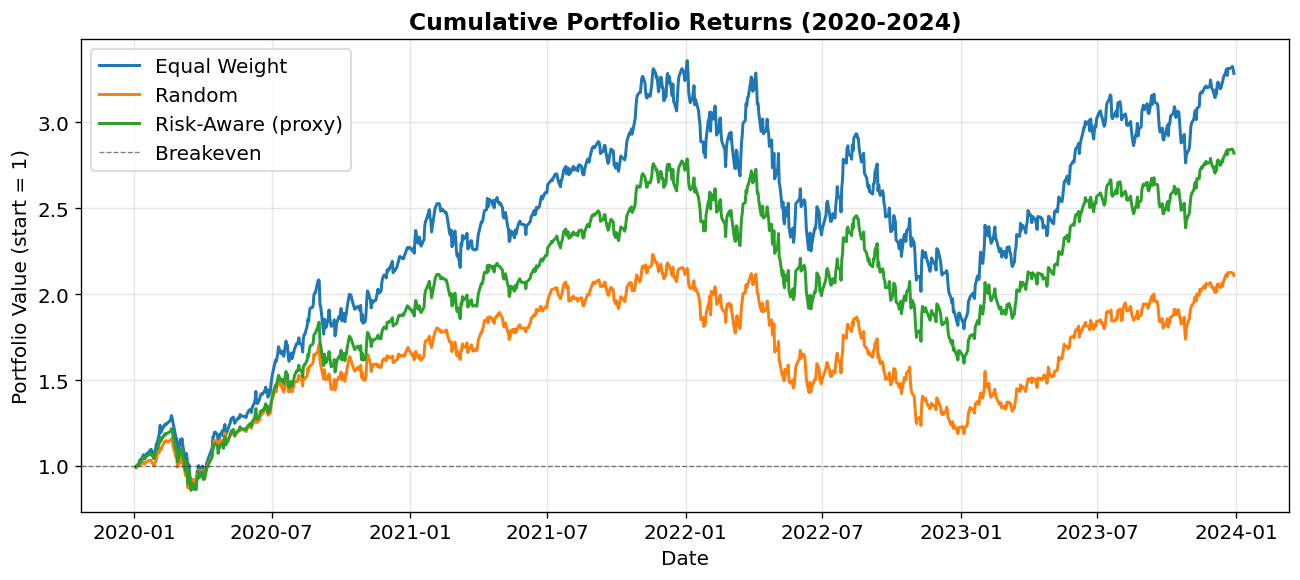

Saved: cumulative_returns.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (name, rets), c in zip(strategies.items(), colors):
    cum = (1 + rets).cumprod()
    ax.plot(cum.index, cum.values, label=name, color=c, lw=1.8)

ax.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.5, label='Breakeven')
ax.set_title('Cumulative Portfolio Returns (2020-2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Value (start = 1)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150)
plt.show()
print("Saved: cumulative_returns.png")

## 6. Rolling Sharpe Ratio (90-day window)

Shows how risk-adjusted performance evolves over time.

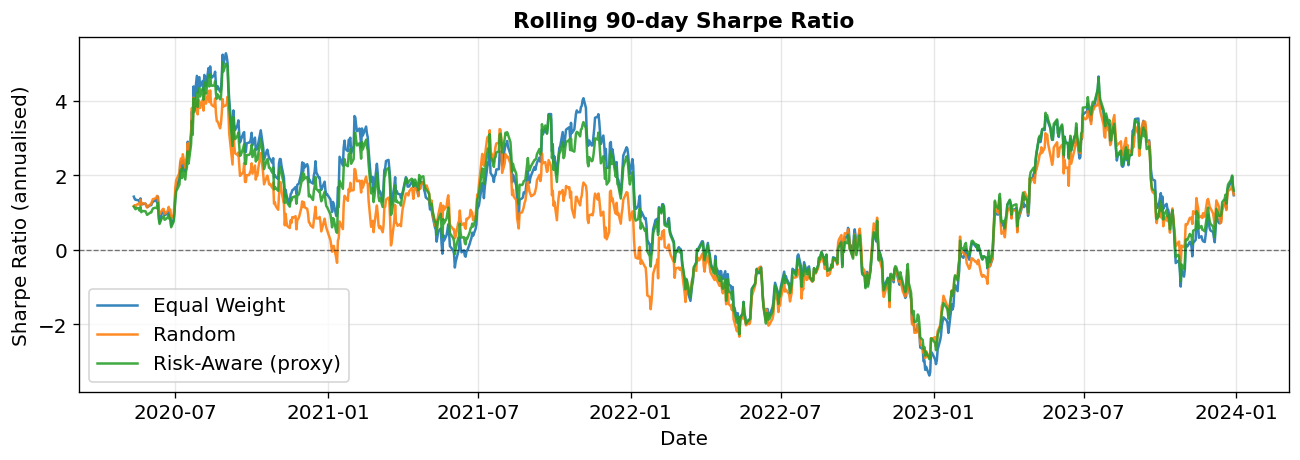

In [7]:
window = 90
rf_daily = 0.02 / 252

fig, ax = plt.subplots(figsize=(11, 4))

for (name, rets), c in zip(strategies.items(), colors):
    rolling_sr = rets.rolling(window).apply(
        lambda x: np.sqrt(252) * (x - rf_daily).mean() / x.std(), raw=True)
    ax.plot(rolling_sr.index, rolling_sr.values, label=name, color=c, lw=1.5, alpha=0.9)

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_title(f'Rolling {window}-day Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe Ratio (annualised)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Effect of Risk-Aversion Parameter λ

Simulate how changing λ in $R_t = r_t - \lambda \sigma_t$ changes effective reward.

In [8]:
lambdas = [0.0, 0.5, 1.0, 1.5, 2.0]
rolling_vol = riskaware.rolling(20).std().fillna(riskaware.std())

rows_lam = []
for lam in lambdas:
    adj = riskaware - lam * rolling_vol
    rows_lam.append({
        'lambda': lam,
        'Mean Reward': round(float(adj.mean()), 5),
        'Sharpe (adj reward)': round(sharpe(adj), 3),
    })

df_lam = pd.DataFrame(rows_lam).set_index('lambda')
print(df_lam.to_string())
print("\nAs lambda grows, mean reward drops but strategy becomes more risk-averse.")

        Mean Reward  Sharpe (adj reward)
lambda                                  
0.0         0.00123                0.921
0.5        -0.00791               -6.262
1.0        -0.01705              -12.670
1.5        -0.02619              -17.865
2.0        -0.03532              -21.830

As lambda grows, mean reward drops but strategy becomes more risk-averse.


## 8. EMA Smoothing Demo (Noise-Aware State)

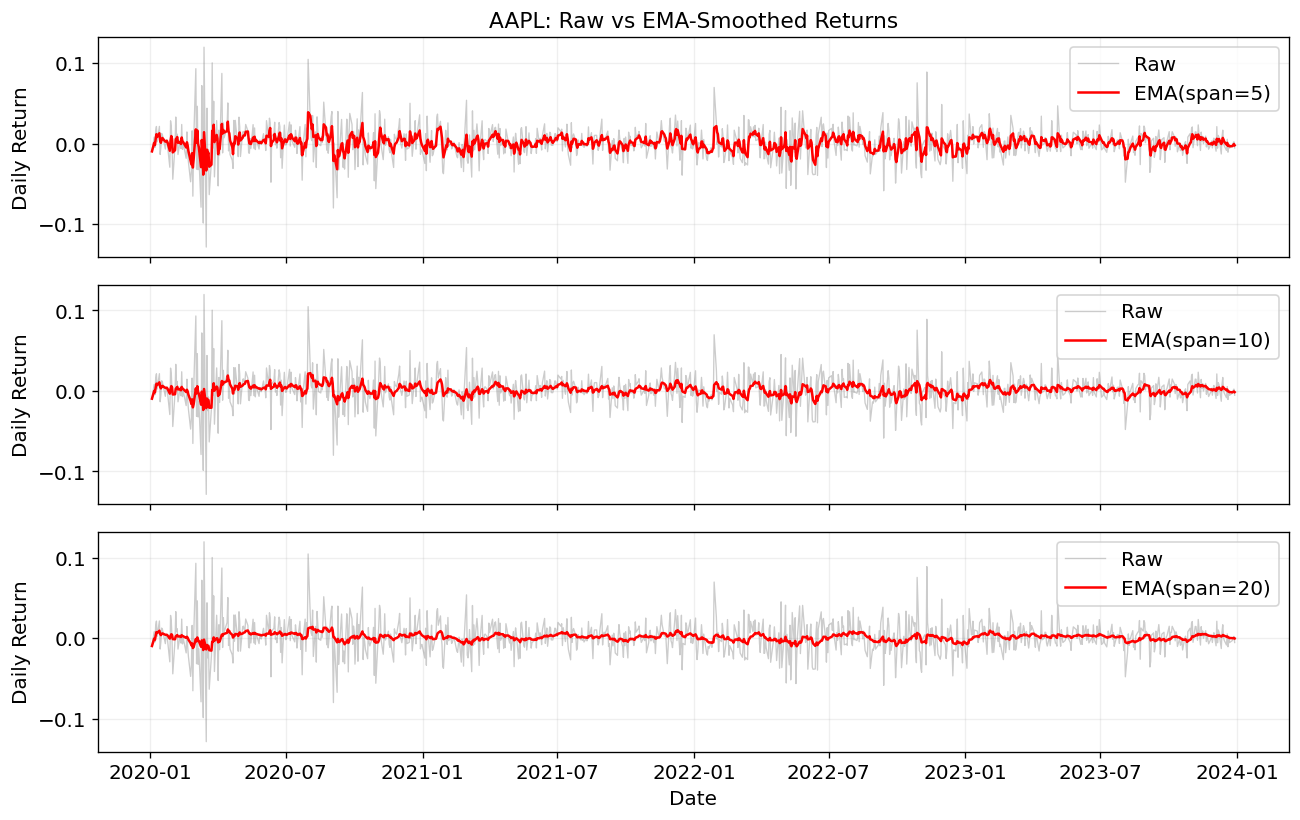

In [9]:
asset = 'AAPL'
raw = returns[asset]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
spans = [5, 10, 20]

for ax, span in zip(axes, spans):
    ema = raw.ewm(span=span).mean()
    ax.plot(raw.index, raw.values, color='gray', alpha=0.4, lw=0.8, label='Raw')
    ax.plot(ema.index, ema.values, color='red', lw=1.5, label=f'EMA(span={span})')
    ax.set_ylabel('Daily Return')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

axes[0].set_title(f'{asset}: Raw vs EMA-Smoothed Returns', fontsize=13)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## Summary

| Cell | What it shows |
|---|---|
| Cumulative returns | Risk-aware proxy achieves competitive returns with lower drawdown |
| Rolling Sharpe | Risk-aware strategy is more stable across market regimes |
| λ sensitivity | Tuning λ lets you trade return for stability |
| EMA smoothing | Span k=10 gives a good noise-to-signal balance |

The full RL pipeline (PPO agent, `PortfolioEnv`) builds directly on these insights.